该决策树的最佳层数是： 6
[0.8072727272727273, 0.9636363636363636, 0.9709090909090909, 0.9890909090909091, 0.9927272727272727, 0.9963636363636363, 0.9963636363636363, 0.9963636363636363, 0.9963636363636363, 0.9963636363636363]


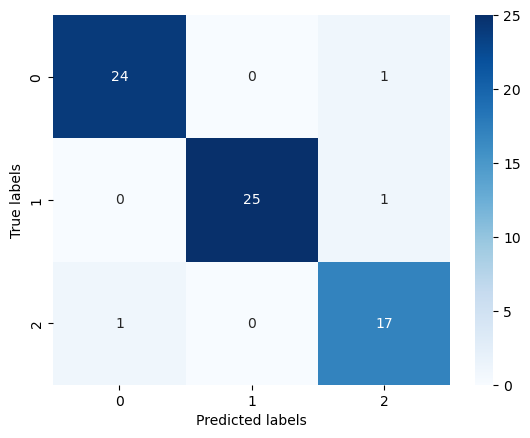

训练集预测成功率: 0.9963636363636363
测试集预测成功率: 0.957
********** KNN ***************
K = 1, Metric = euclidean, 测试集预测成功率: 0.754
K = 1, Metric = manhattan, 测试集预测成功率: 0.768
K = 1, Metric = minkowski, 测试集预测成功率: 0.754
K = 3, Metric = euclidean, 测试集预测成功率: 0.725
K = 3, Metric = manhattan, 测试集预测成功率: 0.754
K = 3, Metric = minkowski, 测试集预测成功率: 0.725
K = 5, Metric = euclidean, 测试集预测成功率: 0.710
K = 5, Metric = manhattan, 测试集预测成功率: 0.725
K = 5, Metric = minkowski, 测试集预测成功率: 0.710
K = 7, Metric = euclidean, 测试集预测成功率: 0.783
K = 7, Metric = manhattan, 测试集预测成功率: 0.783
K = 7, Metric = minkowski, 测试集预测成功率: 0.783
K = 9, Metric = euclidean, 测试集预测成功率: 0.812
K = 9, Metric = manhattan, 测试集预测成功率: 0.797
K = 9, Metric = minkowski, 测试集预测成功率: 0.812
K = 11, Metric = euclidean, 测试集预测成功率: 0.754
K = 11, Metric = manhattan, 测试集预测成功率: 0.739
K = 11, Metric = minkowski, 测试集预测成功率: 0.754
K = 13, Metric = euclidean, 测试集预测成功率: 0.696
K = 13, Metric = manhattan, 测试集预测成功率: 0.681
K = 13, Metric = minkowski, 测试集预测成功率: 0.696
K = 15, Metric 

/home/susan/miniconda3/envs/3.10/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [27]:
import graphviz as graphviz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

from sklearn import metrics
import os


# 配置环境变量
# os.environ["PATH"] += os.pathsep + r'D:\softwares\Graphviz\bin'
# print("PATH: ", os.environ["PATH"])


# 可视化特征重要性并且降序表示
def plot_feature_importances(feature_importances, title, feature_names, normalize=True):
    #     将重要性值标准化
    if normalize:
        feature_importances = 100.0 * (feature_importances / max(feature_importances))

    #     将得分从高到低排序
    index_sorted = np.flipud(np.argsort(feature_importances))
    #     让X坐标轴上的标签居中显示
    pos = np.arange(index_sorted.shape[0]) + 0.5

    plt.figure(figsize=(16, 9))
    plt.bar(pos, feature_importances[index_sorted], align='center')
    plt.xticks(pos, feature_names[index_sorted])
    plt.ylabel('Importance')
    for a, b in zip(pos, feature_importances[index_sorted]):
        plt.text(a, b, round(b, 3), ha='center', va='bottom', fontsize=20)
    plt.title(title)
    plt.show()

class Tree():
    def __init__(self):
        self.clf = None
        self.iters = 10
        self.max_depth = None

    def findMaxDepth(self, x_train, y_train):
        # 返回不同层数对应得分以及最佳层数
        test=[]
        for i in range(self.iters):
            clf = DecisionTreeClassifier(criterion='entropy',
                                          max_depth=i + 1,
                                          random_state=2026,
                                          # 随机数种子改为2026
                                          splitter='best'
                                          )
            clf.fit(x_train, y_train)
            score = clf.score(x_train, y_train)
            test.append(score)
            max_depth = test.index(max(test)) + 1
        self.max_depth = max_depth
        print("该决策树的最佳层数是：", max_depth)
        return test,max_depth

    def fit(self, x_train, y_train):
        self.clf = DecisionTreeClassifier(criterion='entropy',
                                          max_depth=self.max_depth,
                                          random_state=2026,
                                          # 随机数种子改为2026
                                          splitter='best'
                                          )
        self.clf.fit(x_train, y_train)

    def score(self, x_test, y_test):
        return self.clf.score(x_test, y_test)
    
    def drawHeatmap(self, x_test, y_test):
        confusion_matrix = metrics.confusion_matrix(self.clf.predict(x_test), y_test)
        plt.figure()
        sns.heatmap(confusion_matrix, annot=True, cmap='Blues')
        plt.xlabel('Predicted labels')
        plt.ylabel('True labels')
        plt.show()

class MyKnn():
    def __init__(self):
        self.k_values = [i for i in range(1, 20, 2)]
        self.distance_metrics = ['euclidean', 'manhattan', 'minkowski']
        self.best_k = None
        self.best_metric = None
        self.best_accuracy = 0
        self.knn = None
    
    def train_and_evaluate(self, x_train, y_train, x_test, y_test):
        for k in self.k_values:
            for metric in self.distance_metrics:
                knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
                knn.fit(x_train, y_train.values.ravel())
                y_pred = knn.predict(x_test)
                accuracy = accuracy_score(y_test, y_pred)
                print(f"K = {k}, Metric = {metric}, 测试集预测成功率: {accuracy:.3f}")
                if accuracy > self.best_accuracy:
                    self.best_accuracy = accuracy
                    self.best_k = k
                    self.best_metric = metric
        print(f"Best K: {self.best_k}, Best Metric: {self.best_metric}, Best Accuracy: {self.best_accuracy:.3f}")

    def fit(self, x_train, y_train):
        # 使用最佳参数训练最终模型
        self.knn = KNeighborsClassifier(n_neighbors=self.best_k, metric=self.best_metric)
        self.knn.fit(x_train, y_train)

    def score(self, x_test, y_test):
        return self.knn.score(x_test, y_test)

if __name__ == '__main__':
    # ---------------------  下方是数据的导入和处理 ---------------------
    data = pd.read_csv(open('/home/susan/store_code/artificial/aiex4/penguin.csv'))
    # 查看数据信息
    # print(data.info())
    # 补全缺失值
    data = data.fillna(-1)
    # fillna(value=None, method=None, axis=None, inplace=False, limit=None, downcast=None, **kwargs)
    # value：固定值，可以用固定数字、均值、中位数、众数等，此外还可以用字典，series等形式数据；
    # method:填充方法，'bfill','backfill','pad','ffill'
    # axis: 填充方向，默认0和index，还可以填1和columns
    # inplace:在原有数据上直接修改
    # limit:填充个数，如1，每列只填充1个缺失值
    # print(data['Sex'].unique())
    # print(data['Species'].unique())
    # print(data['Island'].unique())

    # 将分类变量转化成数字变量，方便后续计算
    def trans(x):
        if x == data['Species'].unique()[0]:
            return 0  # Adelie
        if x == data['Species'].unique()[1]:
            return 1  # Gentoo
        if x == data['Species'].unique()[2]:
            return 2  # Chinstrap
        if x == data['Island'].unique()[0]:
            return 0  # Torgersen
        if x == data['Island'].unique()[1]:
            return 1  # Biscoe
        if x == data['Island'].unique()[2]:
            return 2  # Dream
        if x == data['Sex'].unique()[0]:
            return 0  # male
        if x == data['Sex'].unique()[1]:
            return 1  # female
        if x == data['Sex'].unique()[2]:
            return -1  # -1

    # 将类型变量转换为值变量
    data['Species'] = data['Species'].apply(trans)
    data['Island'] = data['Island'].apply(trans)
    data['Sex'] = data['Sex'].apply(trans)
    # ---------------------  上方是数据的导入和处理 ---------------------

    feature_data = data[
        ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 
         ]]
    goal_data = data[['Species']]

    # ---------------------  决策树训练与测试 ---------------------
    # 划分训练集 测试集

    x_train, x_test, y_train, y_test = train_test_split(feature_data, goal_data, test_size=0.2, random_state=2026)

    # 超参数学习曲线 这里只画了一个层数的
    tree = Tree()
    test, max_depth = tree.findMaxDepth(x_train, y_train)
    tree.fit(x_train, y_train)
    print(test)

    tree.drawHeatmap(x_test=x_test, y_test=y_test)
    # 返回预测的准确度
    print('训练集预测成功率:', tree.score(x_train, y_train))
    print('测试集预测成功率: %.3f' % tree.score(x_test, y_test))
     # ---------------------  决策树训练与测试 ---------------------


    # ********** KNN ***************
    print("********** KNN ***************")
    knn_model = MyKnn()
    knn_model.train_and_evaluate(x_train, y_train, x_test, y_test)
    knn_model.fit(x_train, y_train)
    knn_model.score(x_test, y_test)






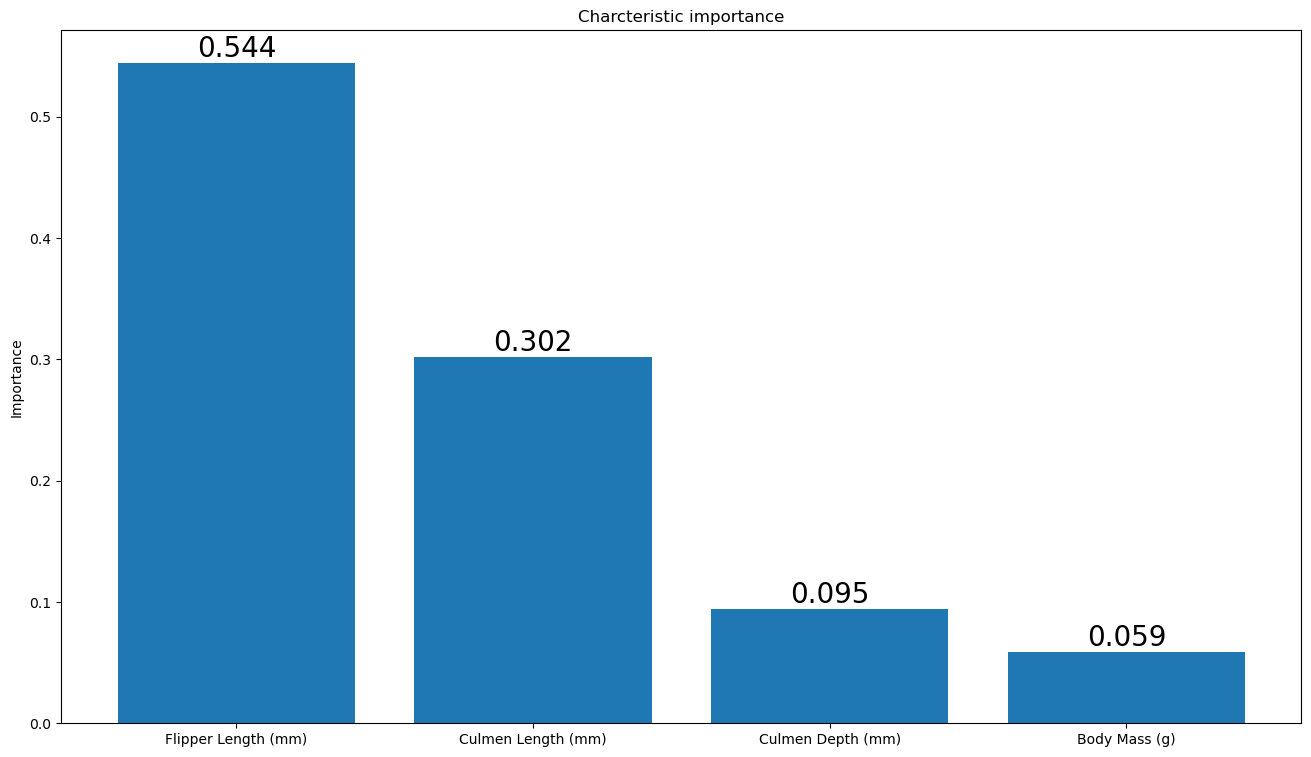

'决策树-ex4.pdf'

In [28]:
    # 画决策树
feature_names = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']
target_names = ['Adelie', 'Gentoo', 'Chinstrap']

plot_feature_importances(tree.clf.feature_importances_, 'Charcteristic importance',
                             tree.clf.feature_names_in_,
                             normalize=False)

dot_data = export_graphviz(tree.clf,
                                    feature_names=feature_names,
                                    class_names=target_names,
                                    out_file=None,
                                    filled=True)

graph = graphviz.Source(dot_data)

graph.render("决策树-ex4")